# Victory Status in Chess

Chess is a game that humans have been playing for over 1400 years. Today, the game is often played virtually through applications like chess.com or lichess.org. Due to the popularity of these sites, thousands of games may be played each day and the amount of data collected from all games is massive and extensive.

The Elo system is a ranking system to assign a numerical value to the chess skill of any given player. The original purpose of this system is to be able to determine the odds that a player will win over their opponent. Upon winning, a player’s Elo rating goes up, and the opposite is true upon losing. The amount these values change depends on the discrepancy between the two ratings.

There are a few ways for a chess match to end. A player could checkmate their opponent (win), the match could end in a stalemate (draw), the time clock could run out on the opponents clock (win), or they could resign (win). 


# Predictive Question

In this project, we will develop a model to predict the victory status of any game based on the difference in rating associated with each player and the color of each player in a chess match: draw, resign, clock, or mate.

# Preliminary Exploratory Data Analysis

In [2]:
# Run this code first
library(repr)
library(tidyverse)
library(tidymodels)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.0 ──

✔ ggplot2 3.3.2     ✔ purrr   0.3.4
✔ tibble  3.0.3     ✔ dplyr   1.0.2
✔ tidyr   1.1.2     ✔ stringr 1.4.0
✔ readr   1.3.1     ✔ forcats 0.5.0

Warning message:
“package ‘ggplot2’ was built under R version 4.0.1”
Warning message:
“package ‘tibble’ was built under R version 4.0.2”
Warning message:
“package ‘tidyr’ was built under R version 4.0.2”
Warning message:
“package ‘dplyr’ was built under R version 4.0.2”
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Warning message:
“package ‘tidymodels’ was built under R version 4.0.2”
── Attaching packages ────────────────────────────────────── tidymodels 0.1.1 ──

✔ broom     0.7.0      ✔ recipes   0.1.13
✔ dials     0.0.9      ✔ rsample   0.0.7 
✔ infer     0.5.4      ✔ tune      0.1.1 
✔ modeldata 0.0.2      ✔ workflows 0.2.0 
✔ parsnip   0.1.3    

In [3]:
chess <- read_csv("https://raw.githubusercontent.com/m1ndst0rmz/DSCI-GroupProject/main/games.csv") %>%
select(victory_status, turns, winner, white_id, black_id, white_rating, black_rating, rated)

chess_victory_status <- chess %>%
group_by(victory_status, winner) %>%
summarize(n=n())

Parsed with column specification:
cols(
  id = col_character(),
  rated = col_logical(),
  created_at = col_double(),
  last_move_at = col_double(),
  turns = col_double(),
  victory_status = col_character(),
  winner = col_character(),
  increment_code = col_character(),
  white_id = col_character(),
  white_rating = col_double(),
  black_id = col_character(),
  black_rating = col_double(),
  moves = col_character(),
  opening_eco = col_character(),
  opening_name = col_character(),
  opening_ply = col_double()
)

`summarise()` regrouping output by 'victory_status' (override with `.groups` argument)



This is the split of the data into training data and testing data.

In [10]:
#split the data into training and testing sets
chess_split <- initial_split(chess, prop = 0.75, strata = victory_status)
chess_train <- training(chess_split)
chess_test <- testing(chess_split)
glimpse(chess_train)

Rows: 15,044
Columns: 8
$ victory_status <chr> "mate", "mate", "draw", "resign", "resign", "mate", "m…
$ turns          <dbl> 61, 61, 5, 33, 9, 119, 39, 38, 31, 31, 43, 52, 66, 101…
$ winner         <chr> "white", "white", "draw", "white", "black", "white", "…
$ white_id       <chr> "ischia", "daniamurashov", "trelynn17", "capa_jr", "da…
$ black_id       <chr> "a-00", "adivanov2009", "franklin14532", "daniel_likes…
$ white_rating   <dbl> 1496, 1439, 1250, 1520, 1413, 1381, 1381, 1381, 1381, …
$ black_rating   <dbl> 1500, 1454, 1002, 1423, 2108, 1209, 1272, 1867, 1607, …
$ rated          <lgl> TRUE, TRUE, FALSE, TRUE, FALSE, TRUE, FALSE, FALSE, FA…


This is a visualization of the breakdown of all games and how they end.

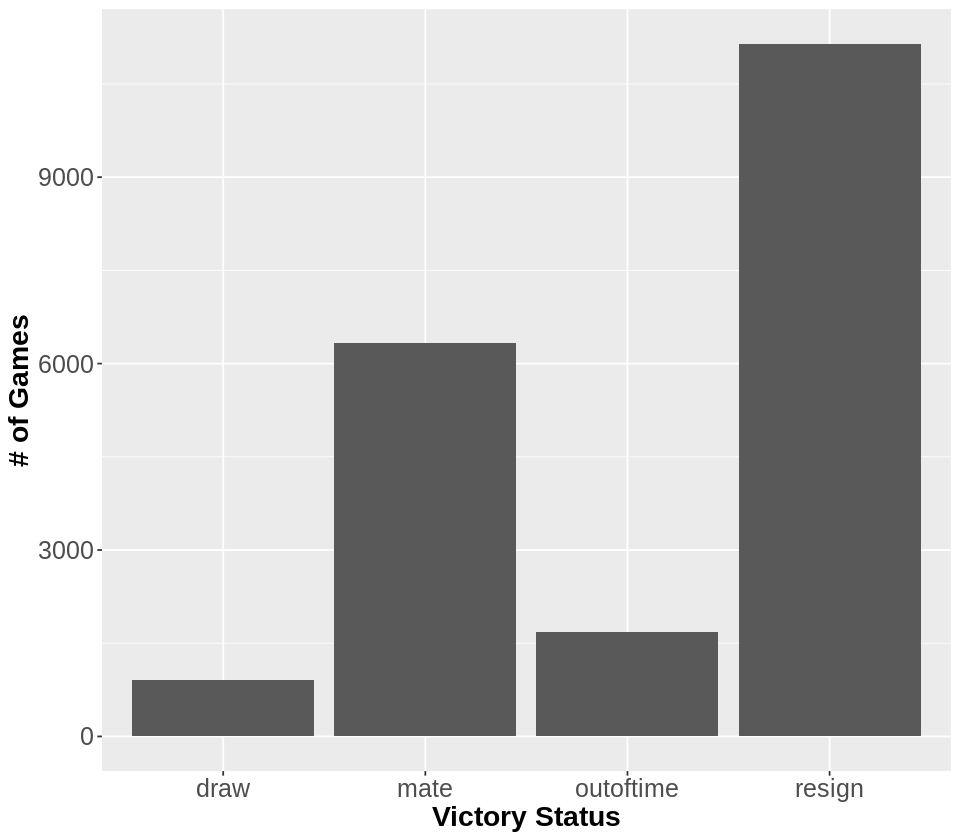

In [6]:
options(repr.plot.width = 10, repr.plot.width = 8)

chess_victory_status_plot <- chess_victory_status %>%
ggplot(aes(x = victory_status, y = n)) +
geom_bar(stat = "identity") +
labs(x = "Victory Status", y = "# of Games") +
theme(axis.text=element_text(size=15),
     axis.title=element_text(size=17,face="bold"))

chess_victory_status_plot

This is a visualization of the rating of players in each match in this data set.

In [7]:
# If we need, here is all the unique player ids
chess_player_ids <- chess %>%
select(white_id, black_id) %>%
pivot_longer(c(white_id, black_id), values_to = "player_id") %>%
select(player_id) %>%
distinct()

`summarise()` ungrouping output (override with `.groups` argument)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



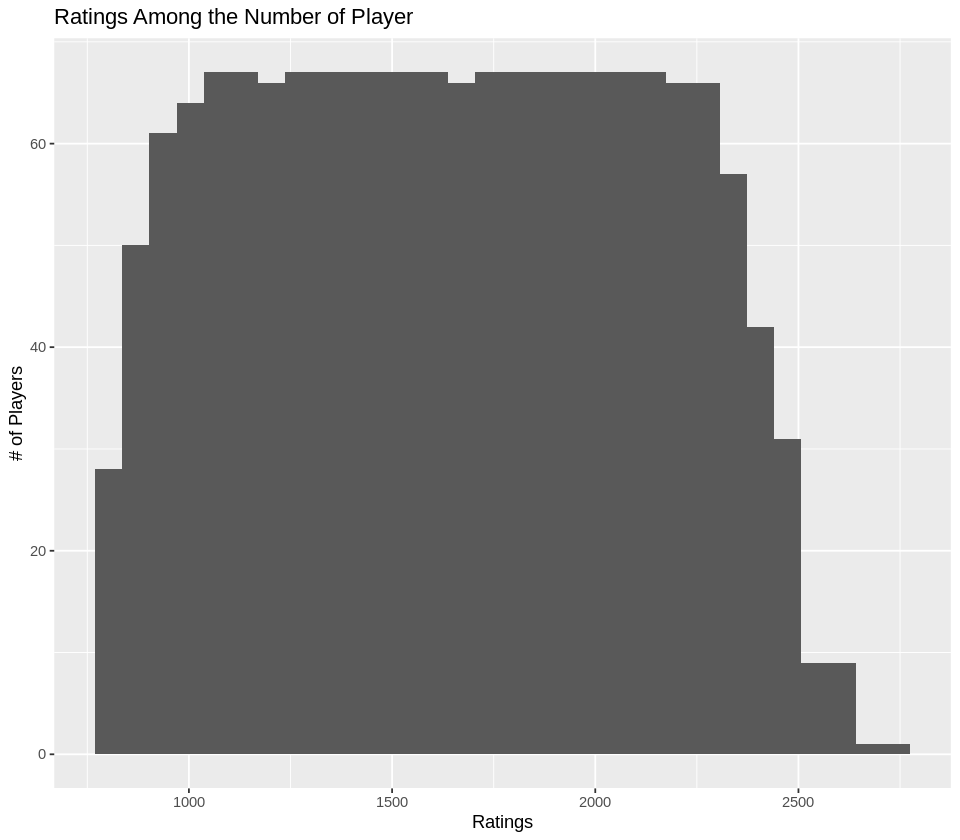

In [9]:
chess_player_ratings <- chess %>%
select(white_rating, black_rating) %>%
pivot_longer(c(white_rating, black_rating), values_to = "rating") %>%
select(rating) %>%
group_by(rating) %>%
summarize(n = n())

chess_player_ratings_plot <- chess_player_ratings %>%
ggplot(aes(x = rating)) +
geom_histogram() +
labs(x = "Ratings", y = "# of Players")+
ggtitle("Ratings Among the Number of Player")

chess_player_ratings_plot

# Expectations

From this data we predict that we will see a higher number of resignations in higher ratings. We also expect to see more run-out-of-time endings in the lower ratings. We predict that draws will be more likely as the rating gets higher and that check mates will be fairly consistent throughout the ratings.

These findings may become useful to inform players decisions as to how they play. For example, if they know that (based on their rating) they are more likely to draw, they may play in such a way to avoid stale mates. In a more realistic sense these findings will largely not serve much of a purpose than simply be interesting to chess players.

Future questions these predictions could lead to might be: Why are we more likely to find this or that victory state in certain ratings? Are there factors that are not being monitored that might change these results? Are these results consistent with real life chess tournaments or are they unique to online chess matches?